# An alert just arrived. Where do you point first?

*Reading this on the docs site? Every cell below is already executed and ready to browse. Want to run it yourself instead? [Open this notebook in Google Colab](https://colab.research.google.com/github/astro-transients/tilepy/blob/main/docs/tutorials/quickstart_tilepy.ipynb).*

A gravitational-wave detector network just reported a candidate merger. Somewhere
in a region that can span hundreds of square degrees, there may be a fading
optical counterpart. Your telescope's field of view covers a tiny fraction of
that region. You cannot observe everywhere at once, so where do you look
*first*, and *why*?

This notebook answers that question step by step, using **tilepy**:

1. what the localization map actually *is* (a HEALPix probability map),
2. how its resolution works, and why that resolution is a trade-off,
3. how to extract "the region that matters" (the 90% credible area),
4. how tilepy turns that region into an ordered list of pointings,
5. and finally, a full run on a real event, ending with the answer to our
   opening question.

Every idea below comes with a plot or a number right next to it. Nothing is
asked to be taken on faith.

## 0. Setup

This notebook runs the same way on **Google Colab** or on a **local
installation**. The cell below detects which one you are in and installs
tilepy only if needed.

In [1]:
import sys

# Are we running on Google Colab, or locally?
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running on Google Colab: installing tilepy from PyPI...")
    %pip install -q tilepy
else:
    try:
        import tilepy

        print("Running locally: tilepy is already installed.")
    except ImportError as exc:
        raise ImportError(
            "tilepy is not installed in this environment. "
            "Install it with `pip install tilepy` and restart the kernel."
        ) from exc

Running locally: tilepy is already installed.


tilepy generates many intermediate diagnostic plots while it computes a
schedule (visibility masks, per-tile zooms, ranking...). With Jupyter's
default inline backend, matplotlib would auto-display every single one of
them here, but we only want to see the plots *we* ask for. Switching to the
non-interactive "Agg" backend keeps things tidy; we explicitly `display(...)`
the results we care about.

In [2]:
import ssl
from io import BytesIO

import certifi
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
from IPython.display import Image, display

# Some networks/CI environments have outdated CA bundles; point Python at
# certifi's, so map downloads over HTTPS do not fail on certificate checks.
ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

import tilepy


def show_fig(fig):
    """Render a matplotlib Figure as a PNG, regardless of the active backend."""
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.getvalue()))


print("tilepy version:", tilepy.__version__)

tilepy version: 3.0.2.dev225+g0c46cf4bb


## 1. What a localization map looks like

When LIGO/Virgo/KAGRA report a candidate, they publish a **HEALPix** map: the
sky is tiled into equal-area pixels, and each pixel carries the probability
that the source lies inside it. Let's look at a real one: the map for event
GW190728 (`S190728q`), fetched directly from GraceDB with `ligo.skymap`, the
standard tool for reading these files.

/Users/rk281962/CEA/Tilepy/tilepy/.venv/lib/python3.11/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/Users/rk281962/CEA/Tilepy/tilepy/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This map has 12,582,912 pixels at NSIDE=1024.


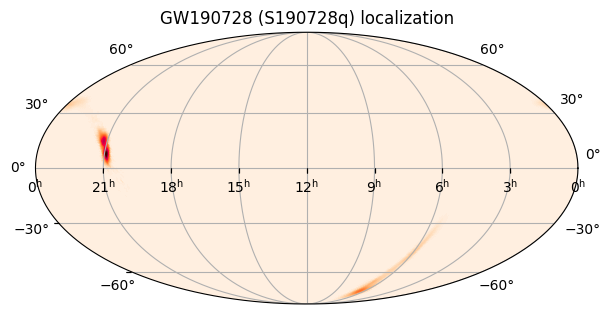

In [3]:
import healpy as hp
import ligo.skymap.plot  # noqa: F401  (registers the "astro ..." projections)
from ligo.skymap.io import read_sky_map

url = (
    "https://gracedb.ligo.org/api/superevents/S190728q/files/"
    "GW190728_064510_PublicationSamples_flattened.fits.gz,0"
)

prob, meta = read_sky_map(url)  # prob[i] = probability of pixel i
nside = hp.npix2nside(len(prob))
print(f"This map has {len(prob):,} pixels at NSIDE={nside}.")

fig = plt.figure(figsize=(7, 4))
ax = plt.axes(projection="astro hours mollweide")
ax.imshow_hpx((prob, "ICRS"), cmap="cylon")
ax.grid()
ax.set_title("GW190728 (S190728q) localization")
show_fig(fig)

Darker orange means higher probability density. This particular event is
reasonably well localized; some events are much more spread out, covering a
long, thin crescent across a third of the sky.

`read_sky_map` returned a **flat** map: every pixel at the same resolution.
That resolution is our next stop: it controls both how precise the map is
*and* how expensive it is to work with.

## 2. NSIDE and resolution: see the trade-off yourself

HEALPix is **hierarchical**: the sphere starts as 12 base pixels, and each one
is recursively split into 4. The resolution is set by a single integer,
`NSIDE` (always a power of 2):

$$N_\mathrm{pix} = 12 \times \mathrm{NSIDE}^2, \qquad
\theta_\mathrm{pix} \approx \frac{58.6°}{\mathrm{NSIDE}}$$

Every pixel covers the *same* solid angle, so `NSIDE` alone tells you both the
number of pixels and their angular size. Higher `NSIDE` means finer detail, at the cost of many more pixels to
compute over.

To play with this without waiting on a network download every time, we build
a **synthetic** localization: a Gaussian probability blob centered on a made-up
sky position. tilepy can generate this in-memory with `set_gaussian_source`, producing
the same object type it would build from a real downloaded map, just
without the download.

In [4]:
from tilepy.include.CampaignDefinition import ObservationParameters, set_gaussian_source
from tilepy.include.MapManagement.MapReader import create_map_reader
from tilepy.include.MapManagement.SkyMap import SkyMap

# A minimal configuration: enough for tilepy to build and read a map.
# (The full meaning of these fields is covered in section 4; ignore them for now.)
demo_config = """[observatory]
name = CTAO-N
lat = 28.75
lon = -17.5
height = 2200

[visibility]
sunDown = -18
moonDown = -0.5
moonGrey = 65
moonPhase = 60
minMoonSourceSeparation = 30
maxMoonSourceSeparation = 145

[operations]
maxZenith = 70
FOV = 2.0
maxRuns = 20
maxNights = 1
duration = 15
minDuration = 10
useGreytime = False

[tiling]
minimumProbCutforCatalogue = 0.01
minProbcut = 0.002
distCut = 500
doPlot = False
secondRound = False
zenithWeighting = 0.75
percentageMOC = 0.90
reducedNside = 128
HRnside = 512
mangrove = False
algorithm = 2D
strategy = integrated
doRank = False
countPrevious = False
countSubtractedPointingsOutside = False

[general]
downloadMaxRetry = 3
downloadWaitPeriodRetry = 20
"""

import tempfile
from pathlib import Path

demo_cfg_file = Path(tempfile.mkdtemp(prefix="tilepy_edu_")) / "demo.ini"
demo_cfg_file.write_text(demo_config)

obspar = ObservationParameters()
set_gaussian_source(obspar, ra=240.0, dec=20.0, sigma=5.0)  # a 5°-wide blob
obspar.from_configfile(demo_cfg_file)

raw_map = create_map_reader(obspar)
synthetic_skymap = SkyMap(obspar, raw_map)
print("Synthetic map ready, mode:", obspar.mode)

Synthetic map ready, mode: gaussian


Now let's render the *same* synthetic sky at three different `NSIDE` values,
and read off the numbers as we go.

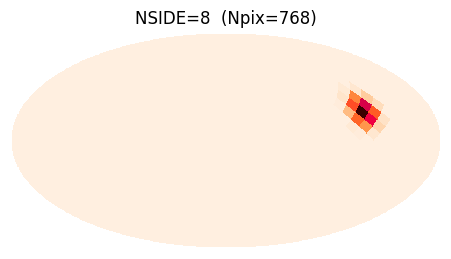

NSIDE=   8 ->       768 pixels, each 53.7 deg^2 wide (7.33° across)


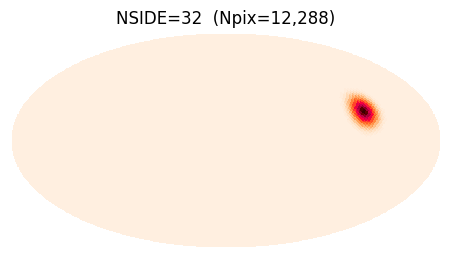

NSIDE=  32 ->    12,288 pixels, each 3.36 deg^2 wide (1.83° across)


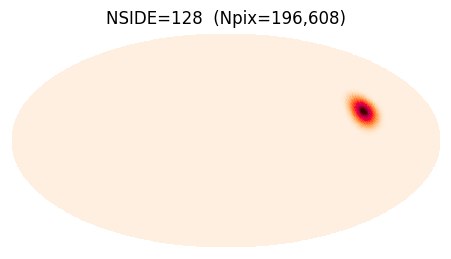

NSIDE= 128 ->   196,608 pixels, each 0.21 deg^2 wide (0.46° across)


In [5]:
def show_resolution(skymap, nside):
    """Render the map at a given NSIDE and print its key numbers."""
    npix = hp.nside2npix(nside)
    pix_area = 41253.0 / npix  # deg^2 per pixel (41253 deg^2 = full sky)
    pix_size = 58.6 / nside  # deg, approximate pixel width

    prob = skymap.getMap("prob", nside)

    fig = plt.figure(figsize=(4.5, 3.2))
    hp.mollview(
        prob,
        nest=skymap.is_nested,
        cmap="cylon",
        title=f"NSIDE={nside}  (Npix={npix:,})",
        cbar=False,
        fig=fig.number,
    )
    show_fig(fig)

    print(
        f"NSIDE={nside:4d} -> {npix:9,} pixels, "
        f"each {pix_area:.3g} deg^2 wide ({pix_size:.2f}° across)"
    )


for nside in (8, 32, 128):
    show_resolution(synthetic_skymap, nside)

The shape barely changes, but the pixel count jumps by a factor of 16 each
time (×4 per doubling of `NSIDE`, and we doubled twice). This is exactly the
trade-off tilepy has to manage: a low `NSIDE` is fast to scan but coarse; a
high `NSIDE` is precise but expensive. That is why tilepy actually uses **two**
resolutions at once, configurable in the `.ini` file:

* `reducedNside`: a coarse grid, used to scan the sky quickly;
* `HRnside`: a fine grid, used to integrate the probability inside a field of
  view precisely once a candidate direction is found.

You will see both again in section 4.

## 3. Extracting "the region that matters"

We rarely want the whole sky map. We want the smallest region that has, say,
90% of the total probability of containing the source. The recipe is simple
and is called a **greedy** algorithm:

1. sort pixels from most to least probable,
2. accumulate their probability,
3. keep pixels until the running total reaches 90%.

Let's do it by hand once, on our synthetic map, to see exactly what is
happening.

1714 pixels out of 196,608 make up the 90% region -> 359.6 deg^2


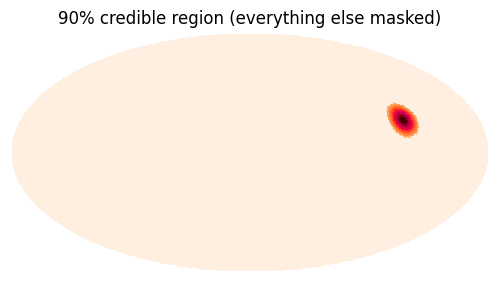

In [6]:
import numpy as np

prob = synthetic_skymap.getMap("prob", 128)

order = np.argsort(prob)[::-1]  # pixel indices, most probable first
cumulative = np.cumsum(prob[order])
pix_90 = order[cumulative <= 0.90]  # the pixels that make up the 90% region

pix_area = hp.nside2pixarea(128, degrees=True)
area_90 = len(pix_90) * pix_area
print(
    f"{len(pix_90)} pixels out of {len(prob):,} make up the 90% region "
    f"-> {area_90:.1f} deg^2"
)

# Highlight those pixels on the map
highlight = np.zeros_like(prob)
highlight[pix_90] = prob[pix_90]

fig = plt.figure(figsize=(5, 3.5))
hp.mollview(
    highlight,
    nest=synthetic_skymap.is_nested,
    cmap="cylon",
    title="90% credible region (everything else masked)",
    cbar=False,
    fig=fig.number,
)
show_fig(fig)

tilepy does exactly this internally, so you rarely need to write the loop
above yourself. Once a map is loaded into a `SkyMap` object (as we already did
for `synthetic_skymap`), the same computation is one line away:

In [7]:
from tilepy.include.PointingTools import GetRegionPixReduced

# Area and pixel indices, computed by tilepy directly:
print("Area (tilepy):", synthetic_skymap.getArea(0.9))
print("Number of pixels (tilepy):", len(synthetic_skymap.getPixIdArea(0.9)))

# And the (RA, Dec) coordinates on the *reduced* grid tilepy scans during
# scheduling; this is the actual list of candidate positions it will visit:
prob_reduced = synthetic_skymap.getMap("prob", obspar.reducedNside)
ra, dec, area = GetRegionPixReduced(
    prob_reduced, 0.9, obspar.reducedNside, synthetic_skymap.scheme
)
print(f"GetRegionPixReduced: {len(ra)} candidate positions, {area:.1f} deg^2")

Area (tilepy): 359.21768015037946 deg2
Number of pixels (tilepy): 428
GetRegionPixReduced: 1714 candidate positions, 359.6 deg^2


The two area estimates are close but not identical: one used the
high-resolution grid, the other the reduced grid. That small gap *is* the
resolution trade-off from section 2, made concrete.

## 4. From region to schedule

We now have a ranked list of candidate sky positions. Turning that into an
actual observation plan means asking, for each position: is it above the
horizon? Is it dark? Is the Moon too close? tilepy's `GetSchedule` answers
these for you, in 2D mode:

1. reads the map and computes the 90% region (section 3);
2. splits the night into observable **dark-time windows** at the observatory;
3. at each window, centers the field of view on the pixel with the **highest
   probability still visible**, adds up the probability contained in the
   field of view, then **masks** those pixels so they are not counted again;
4. repeats until `maxRuns` pointings are scheduled, or the remaining
   probability drops below `minProbcut`.

The result is a table of pointings, ranked by probability, with a proposed
observation time for each. Let's see it on a real event.

## 5. Full pipeline on a real event

This time we use a real localization, downloaded automatically: event
`S240904bv` (a `cWB` search result from the LIGO/Virgo/KAGRA O4 run), and a
fictional telescope at La Palma. Everything tilepy generates (the downloaded
map, plots, tables) is written to a temporary folder, removed automatically
at the end of this section.

In [8]:
import os

originalDir = os.getcwd()
workDir = Path(tempfile.mkdtemp(prefix="tilepy_quickstart_"))
os.chdir(workDir)  # tilepy downloads files using bare relative names

real_cfg_file = workDir / "ExampleConfig.ini"
real_cfg_file.write_text(
    demo_config.replace("doPlot = False", "doPlot = True").replace(
        "doRank = False", "doRank = True"
    )
)

print(f"Temporary working directory: {workDir}")

Temporary working directory: /var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/tilepy_quickstart_uiwne2vd


In [9]:
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.PointingTools import getdate

skymap_url = (
    "https://gracedb.ligo.org/api/superevents/S240904bv/files/cwb.multiorder.fits,0"
)
obsTime = getdate("2024-09-04 14:51:47")

outDir = str(workDir / "output")

obspar_real = ObservationParameters()
obspar_real.add_parsed_args(
    skymap_url, obsTime, str(workDir / "dataset"), None, outDir, None
)
obspar_real.from_configfile(real_cfg_file)

try:
    GetSchedule(obspar_real)
    print("Schedule computed.")
except Exception as e:  # noqa: BLE001
    print("The download or computation failed:", e)
    print(
        "Check that GraceDB (gracedb.ligo.org) is reachable and that the "
        "SSL setup cell above ran successfully."
    )

The filename is cwb.multiorder.fits,0


Starting the 2D pointing calculation with the following parameters



Filename:  G508457


Date: 2024-09-04 14:51:47


Previous pointings: None


...

----------   PLOTTING THE SCHEDULING   ----------


Total covered probability with the scheduled tiles is PGW= 0.05700


list indices must be integers or slices, not str: no galaxies given


cannot access local variable 'ragal' where it is not associated with a value: no galaxies given for plot 2


Schedule computed.


### The answer to our opening question

Where does the telescope look *first*? The highest-ranked row of the
resulting table. Let's read it directly.

In [10]:
import glob

from astropy.io import ascii as ascii_table

resultDir = glob.glob(f"{outDir}/*/PGinFoV")[0]
pointingsFileOut = glob.glob(f"{resultDir}/SuggestedPointings_2DProbOptimisation.txt")[
    0
]

tiles = ascii_table.read(pointingsFileOut)
tiles.sort("PGW", reverse=True)
tiles["Rank"] = range(1, len(tiles) + 1)

first = tiles[0]
print(
    f"First pointing: RA={first['RA[deg]']:.2f} deg, DEC={first['DEC[deg]']:.2f} deg, "
    f"at {first['Time[UTC]']} UTC, covering {first['PGW']:.1%} of the probability "
    f"in a single field of view."
)

tiles["Rank", "Time[UTC]", "RA[deg]", "DEC[deg]", "PGW", "Duration"]

First pointing: RA=93.87 deg, DEC=33.51 deg, at 2024-09-05 03:03:02 UTC, covering 0.4% of the probability in a single field of view.


Rank,Time[UTC],RA[deg],DEC[deg],PGW,Duration
int64,str19,float64,float64,float64,float64
1,2024-09-05 03:03:02,93.8672,33.5101,0.0038,15.0
2,2024-09-05 03:18:02,101.9531,39.8384,0.0036,15.0
3,2024-09-05 02:18:02,89.6311,44.2015,0.0036,15.0
4,2024-09-05 02:48:02,97.8099,44.598,0.0035,15.0
5,2024-09-04 20:48:02,269.6484,-29.3132,0.0032,15.0
6,2024-09-05 02:33:02,94.3805,47.7497,0.003,15.0
7,2024-09-04 21:18:02,253.4766,-15.0948,0.0029,15.0
8,2024-09-04 21:03:02,264.7266,-29.3132,0.0029,15.0
9,2024-09-05 01:48:02,82.8151,45.3892,0.0027,15.0


And here is the full picture: the probability map with every scheduled tile
overlaid, ordered by priority.

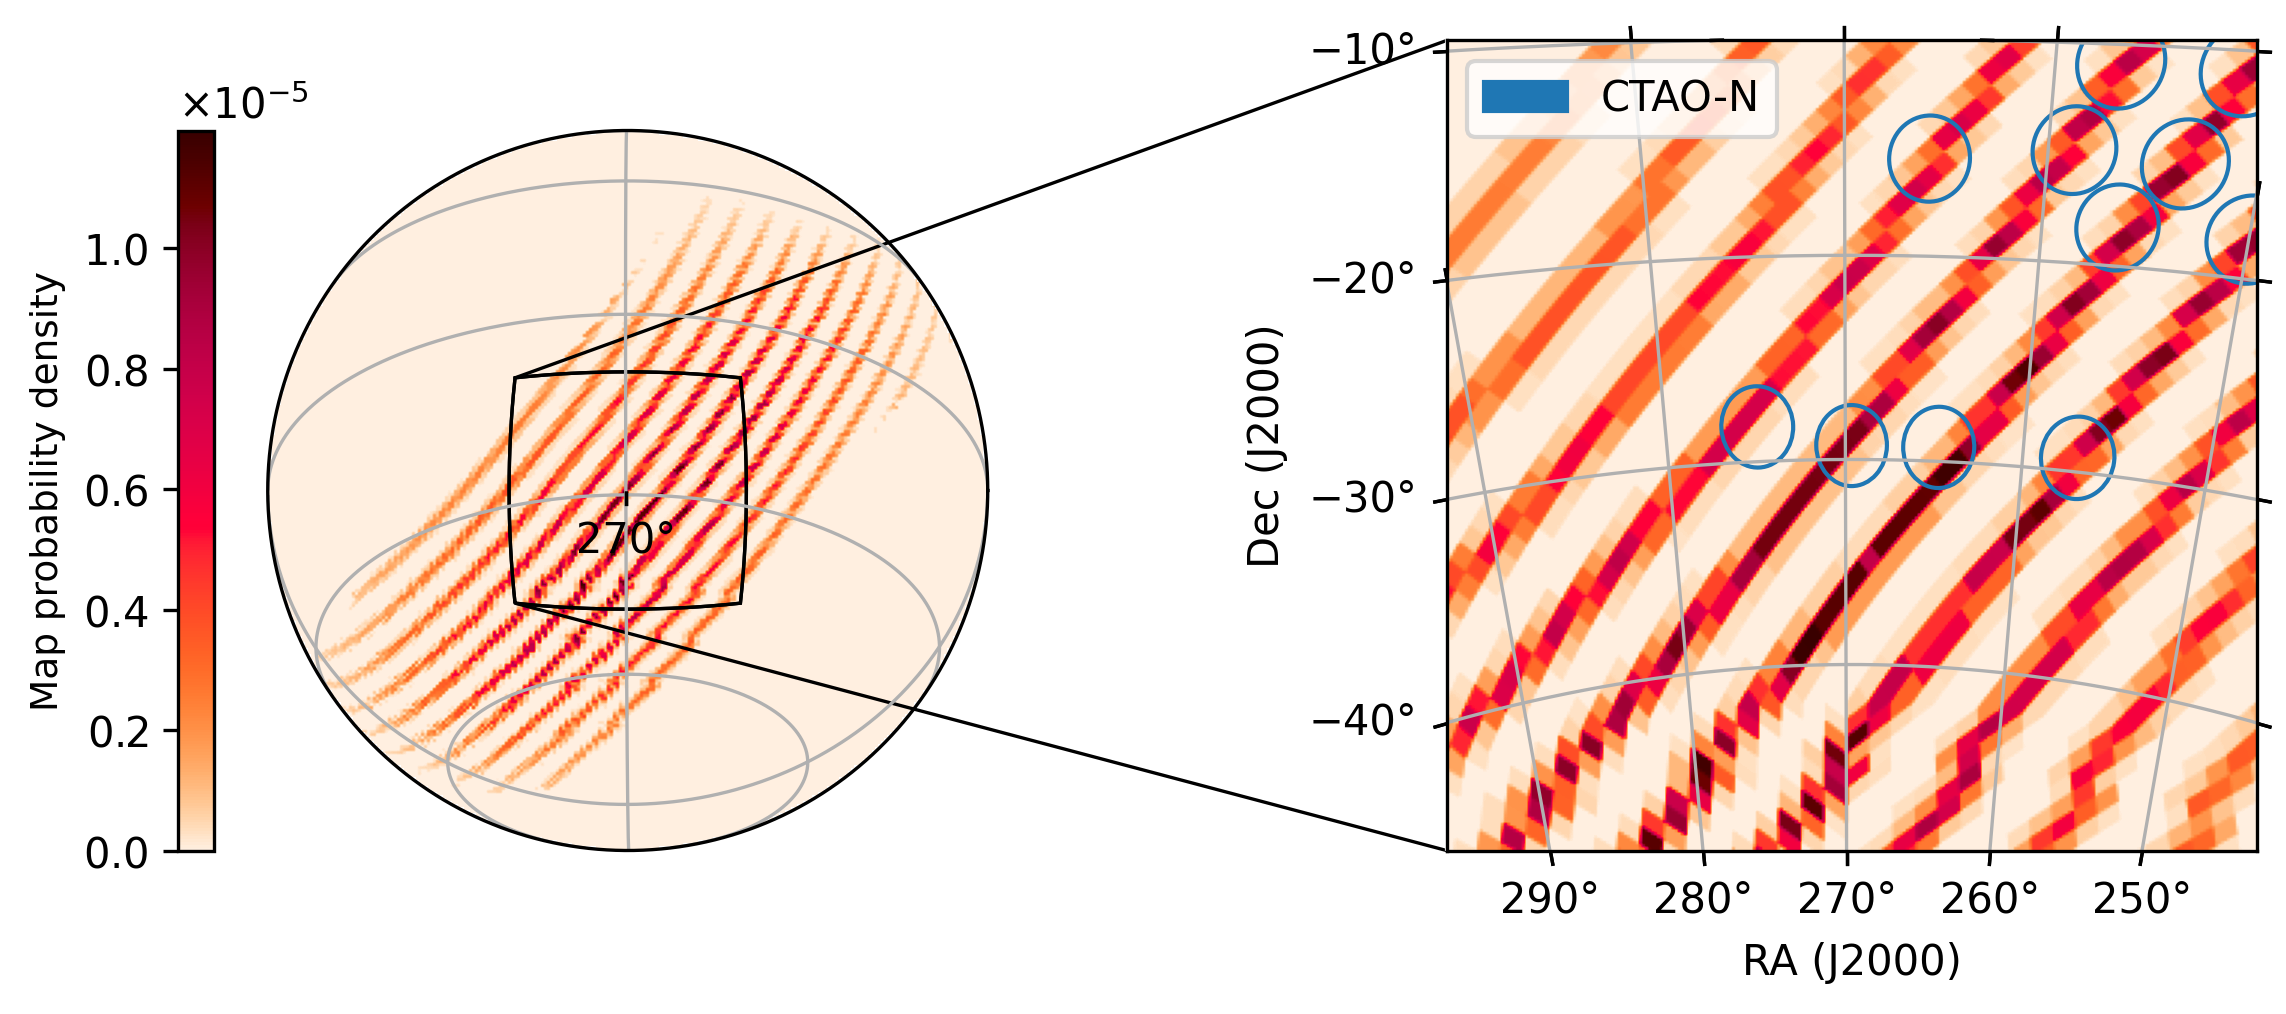

In [11]:
prettyMap = glob.glob(f"{resultDir}/Plot_PrettyMap_*.png")[0]
display(Image(filename=prettyMap))

### Cleaning up

The map, table, and plot above are already displayed inline, so the temporary
folder can be safely removed.

In [12]:
import shutil

os.chdir(originalDir)
shutil.rmtree(workDir, ignore_errors=True)
print(f"Temporary folder removed: {workDir}")

Temporary folder removed: /var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/tilepy_quickstart_uiwne2vd


## 6. Bonus: a historic event, with a different telescope

`S240904bv` showed the full pipeline. To see how easily it adapts to a
**different observatory** and a **different event**, let's redo it with
`GW170817`, the first (and so far only) binary neutron star merger detected
in gravitational waves, on 2017-08-17. It was exceptionally well localized
(~28 deg² at 90%) and its optical counterpart (kilonova AT2017gfo) was
found within hours, a first in multi-messenger astronomy.

This time the telescope is the **LST** (Large-Sized Telescope, CTAO-North's
first prototype), configured with its own visibility constraints. The map
is downloaded once from the public LIGO Document Control Center, so no
GraceDB login is needed.

`GW170817`'s sky region (around declination -20°) was actually below the
horizon from La Palma on the night of the real alert, so, purely to have
something to schedule, we replay the same map on a **later night, a few
months after the alert, when that region is observable from the LST
site**. The map and the science are real; only the observation date is
chosen for the demo.

In [13]:
originalDir = os.getcwd()
workDir = Path(tempfile.mkdtemp(prefix="tilepy_quickstart_gw170817_"))
os.chdir(workDir)  # tilepy downloads files using bare relative names

lst_config = """[observatory]
name = LST
lat = 28.75
lon = -17.5
height = 2200
base = ground

[visibility]
sundown = -18
moondown = -0.5
earthdown = 0
moongrey = 65
gmoonphase = 60
minmoonsourceseparation = 30
maxmoonsourceseparation = 150
SAAThreshold = 0

[operations]
maxzenith = 60
fov = 2.0
maxRuns = 20
maxNights = 3
duration = 30
minduration = 10
useGreytime = False
minSlewing = 0
shape = circle
numberSides = 0
FoVRotation = 0

[tiling]
locCut = 99999
minimumprobcutforcatalogue = 0.01
minProbcut = 0.01
distcut = 0.5
doPlot = True
secondRound = False
zenithWeighting = 0.75
percentageMOC = 0.9
reducedNside = 64
hrnside = 512
mangrove = False
algorithm = 2D
strategy = integrated
doRank = True
countPrevious = False
alphaR = 0
betaR = 0

[general]
downloadMaxRetry = 1
downloadWaitPeriodRetry = 20
"""

lst_cfg_file = workDir / "FollowupParameters_LST.ini"
lst_cfg_file.write_text(lst_config)

print(f"Temporary working directory: {workDir}")

Temporary working directory: /var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/tilepy_quickstart_gw170817_rqxa0_4_


In [14]:
gw170817_url = "https://dcc.ligo.org/public/0146/G1701985/001/bayestar.fits.gz"
obsTime_gw170817 = getdate(
    "2017-12-20 21:00:00"
)  # a night, a few months later, when the field is up from La Palma

outDir_gw170817 = str(workDir / "output")

obspar_gw170817 = ObservationParameters()
obspar_gw170817.add_parsed_args(
    gw170817_url,
    obsTime_gw170817,
    str(workDir / "dataset"),
    None,
    outDir_gw170817,
    None,
)
obspar_gw170817.from_configfile(lst_cfg_file)

try:
    GetSchedule(obspar_gw170817)
    print("Schedule computed.")
except Exception as e:  # noqa: BLE001
    print("The download or computation failed:", e)
    print(
        "Check that the LIGO DCC (dcc.ligo.org) is reachable and that the "
        "SSL setup cell above ran successfully."
    )

The filename is bayestar.fits.gz


Starting the 2D pointing calculation with the following parameters



Filename:  G298107


Date: 2017-12-20 21:00:00


Previous pointings: None


...

----------   PLOTTING THE SCHEDULING   ----------


Total covered probability with the scheduled tiles is PGW= 0.89890


list indices must be integers or slices, not str: no galaxies given


cannot access local variable 'ragal' where it is not associated with a value: no galaxies given for plot 2


Schedule computed.


### Where would the LST have looked?

Same question, same code, a different observatory and a historic event.

In [15]:
resultDir_gw170817 = glob.glob(f"{outDir_gw170817}/*/PGinFoV")[0]
pointingsFileOut_gw170817 = glob.glob(
    f"{resultDir_gw170817}/SuggestedPointings_2DProbOptimisation.txt"
)[0]

tiles_gw170817 = ascii_table.read(pointingsFileOut_gw170817)
tiles_gw170817.sort("PGW", reverse=True)
tiles_gw170817["Rank"] = range(1, len(tiles_gw170817) + 1)

first_gw170817 = tiles_gw170817[0]
print(
    f"First pointing: RA={first_gw170817['RA[deg]']:.2f} deg, "
    f"DEC={first_gw170817['DEC[deg]']:.2f} deg, at {first_gw170817['Time[UTC]']} UTC, "
    f"covering {first_gw170817['PGW']:.1%} of the probability in a single field of view."
)

tiles_gw170817["Rank", "Time[UTC]", "RA[deg]", "DEC[deg]", "PGW", "Duration"]

First pointing: RA=194.06 deg, DEC=-17.58 deg, at 2017-12-21 05:30:00 UTC, covering 35.2% of the probability in a single field of view.


Rank,Time[UTC],RA[deg],DEC[deg],PGW,Duration
int64,str19,float64,float64,float64,float64
1,2017-12-21 05:30:00,194.0625,-17.5828,0.3525,30.0
2,2017-12-21 06:00:00,196.1719,-20.7424,0.2975,30.0
3,2017-12-22 06:12:04,196.1719,-23.318,0.1082,30.0
4,2017-12-22 05:12:04,192.6562,-15.0948,0.0899,30.0
5,2017-12-21 05:00:00,191.25,-12.6356,0.0508,30.0


And the resulting map, tiled by the LST's field of view instead of
CTAO-North's.

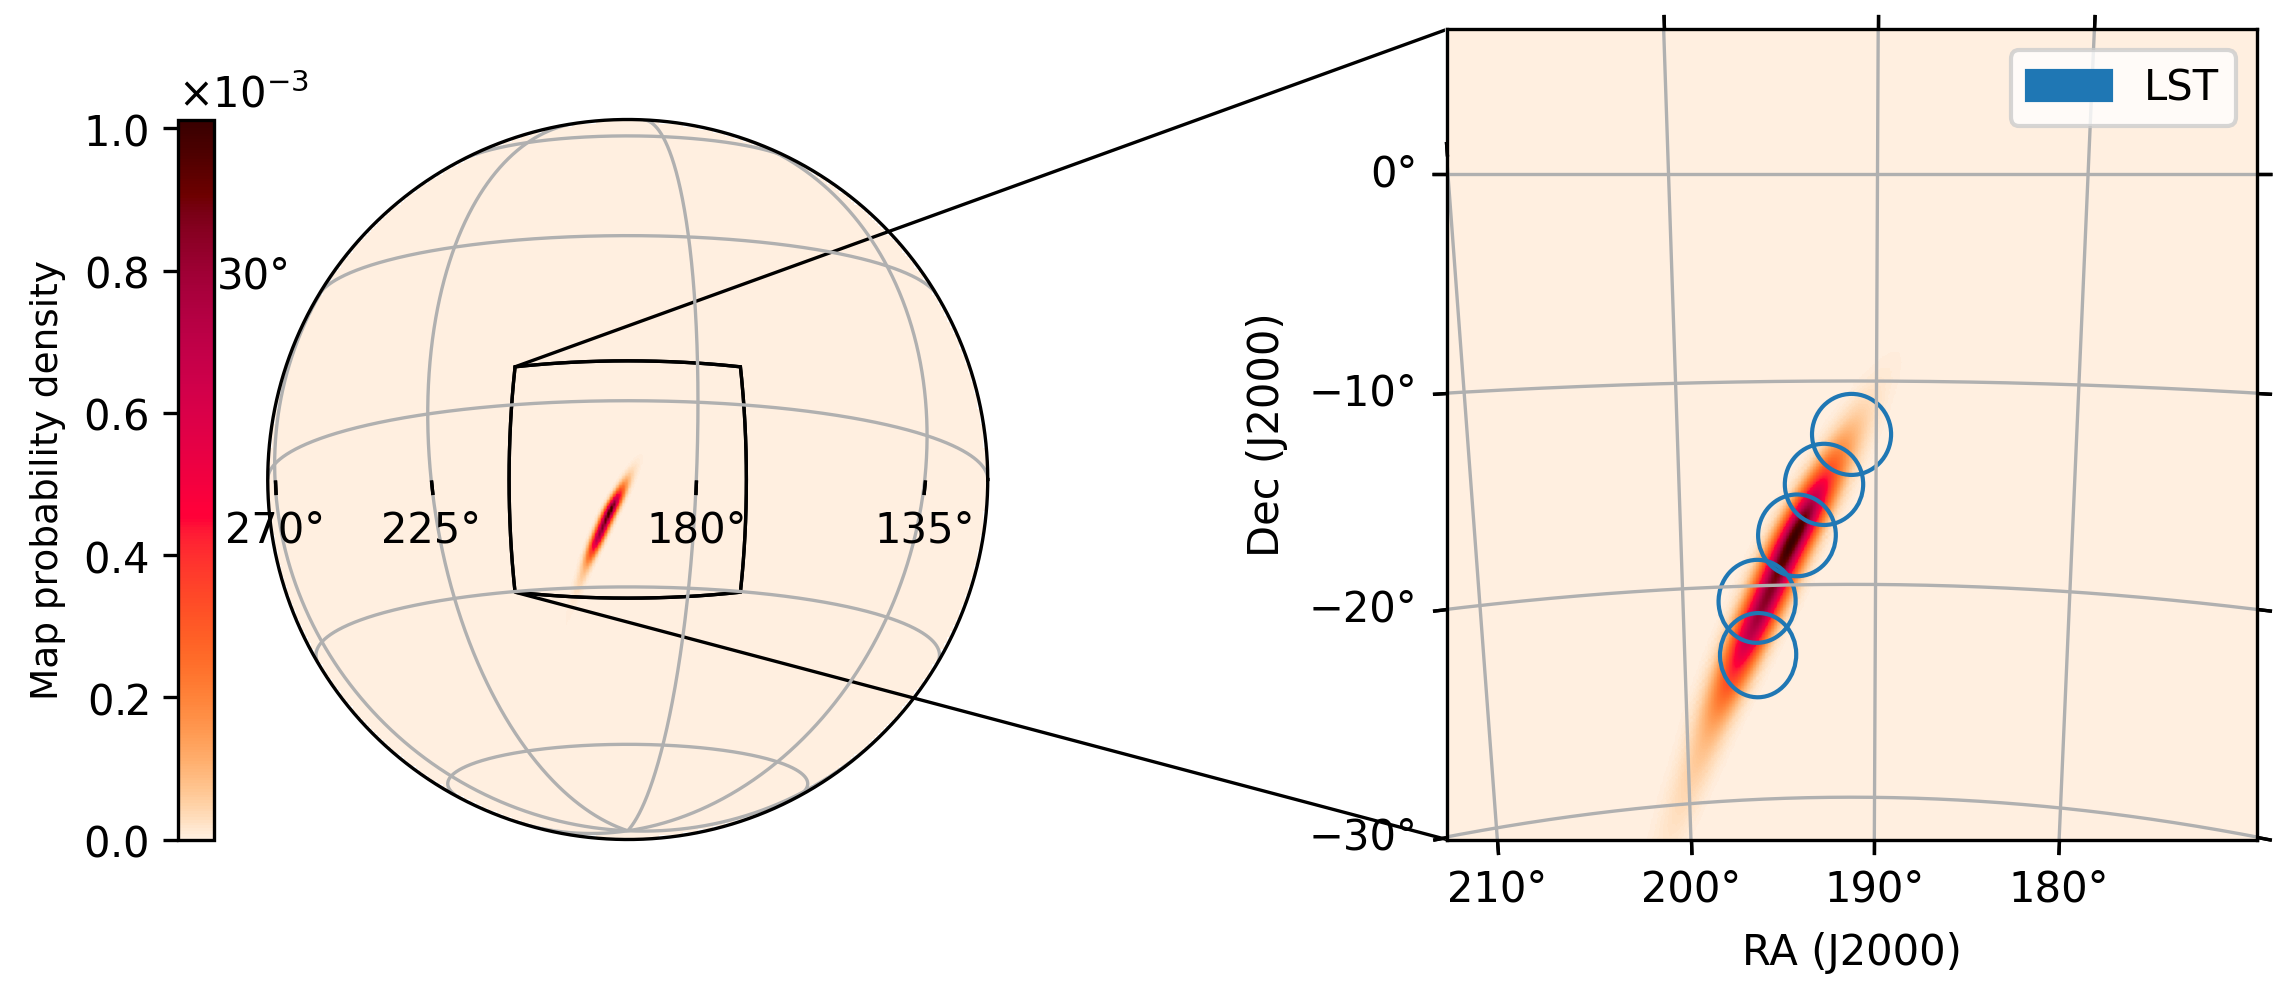

In [16]:
prettyMap_gw170817 = glob.glob(f"{resultDir_gw170817}/Plot_PrettyMap_*.png")[0]
display(Image(filename=prettyMap_gw170817))

### Cleaning up

Same as before: everything above is already displayed inline, so the
temporary folder can be safely removed.

In [17]:
os.chdir(originalDir)
shutil.rmtree(workDir, ignore_errors=True)
print(f"Temporary folder removed: {workDir}")

Temporary folder removed: /var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/tilepy_quickstart_gw170817_rqxa0_4_


## Key takeaways

1. A localization map is a **HEALPix** grid: `NSIDE` sets the trade-off
   between resolution and speed.
2. The **90% credible region** is found by sorting pixels by probability and
   accumulating until the target fraction is reached; tilepy does this for
   you (`SkyMap.getArea`, `SkyMap.getPixIdArea`, `GetRegionPixReduced`).
3. `GetSchedule` turns that region into a **ranked list of pointings**,
   accounting for visibility, darkness, and the Moon.
4. The first row of that list is where the telescope looks first,
   answering the question this notebook opened with.

## Going further

* Full documentation: https://tilepy.readthedocs.io
* Repository and more examples (`examples/launcher`):
  https://github.com/astro-transients/tilepy
* `ligo.skymap` (the library used above to read and display real maps):
  https://git.ligo.org/lscsoft/ligo.skymap
* Community forum:
  https://forum.astro-colibri.science/c/instrumentation-and-tools/tilepy

**Suggested next step**: tilepy also supports a **3D mode**, which weights
tiles using a galaxy catalog (GLADE+) when the event's distance is well
constrained. See the full user guide for details.